# Discrete Probability Distributions, Bernoulli Trials & the Binomial Distribution

**Contents**
1. Setup
2. Discrete probability distribution (PMF, CDF, mean, variance)
3. Bernoulli trials
4. Binomial distribution: definition and formula
5. Building the binomial from scratch (why the formula works)
6. Shape of the binomial distribution
7. Mean of the binomial distribution (with proof)
8. Variance and standard deviation of the binomial distribution (with proof)
9. Mode of the binomial distribution
10. Cumulative probabilities: "at most", "at least", "between"
11. Verifying everything by simulation
12. Normal approximation to the binomial
13. Solved problems (textbook style)
14. Summary & practice problems

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, floor, sqrt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(7)

## 2. Discrete Probability Distribution

A **random variable** X assigns a number to each outcome of an experiment. It is **discrete** if it takes a *countable* set of values (0, 1, 2, ...), such as the number of heads, defective items or customers.

A **discrete probability distribution** lists every possible value $x_i$ together with its probability $p_i = P(X = x_i)$. This function is the **PMF** (probability mass function).

**Two conditions every discrete distribution must satisfy**
1. $0 \le P(X=x_i) \le 1$ for every $i$
2. $\sum_i P(X=x_i) = 1$

**Key quantities**

| Quantity | Formula |
|---|---|
| Mean / Expected value | $\mu = E[X] = \sum x_i\,p_i$ |
| Variance | $\sigma^2 = \text{Var}(X) = \sum (x_i-\mu)^2 p_i = E[X^2] - \mu^2$ |
| Standard deviation | $\sigma = \sqrt{\text{Var}(X)}$ |
| CDF | $F(x) = P(X \le x) = \sum_{x_i \le x} p_i$ |

### Example: number of heads in 2 coin tosses

In [2]:
# Distribution of X = number of heads in 2 fair coin tosses
x = np.array([0, 1, 2])
p = np.array([1/4, 2/4, 1/4])

dist = pd.DataFrame({"x": x, "P(X=x)": p, "CDF P(X<=x)": p.cumsum()})
print(dist.to_string(index=False))

print("\nCondition 1 (all 0<=p<=1):", np.all((p >= 0) & (p <= 1)))
print("Condition 2 (sum = 1)     :", p.sum())

mean = np.sum(x * p)
ex2  = np.sum(x**2 * p)
var  = ex2 - mean**2
print(f"\nMean = {mean}, E[X^2] = {ex2}, Variance = {var}, SD = {np.sqrt(var):.4f}")

 x  P(X=x)  CDF P(X<=x)
 0    0.25         0.25
 1    0.50         0.75
 2    0.25         1.00

Condition 1 (all 0<=p<=1): True
Condition 2 (sum = 1)     : 1.0

Mean = 1.0, E[X^2] = 1.5, Variance = 0.5, SD = 0.7071


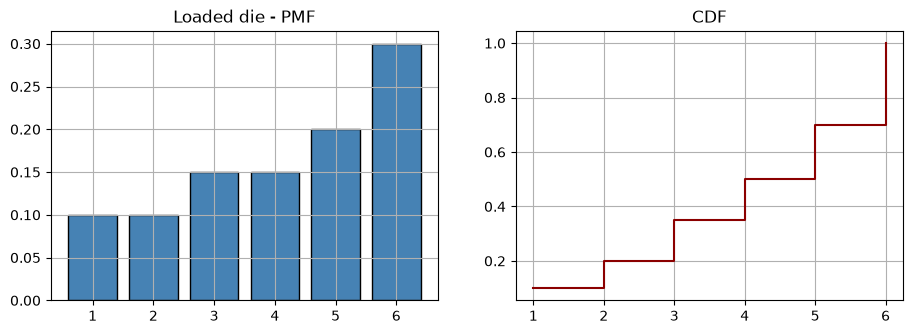

mean=4.150, variance=2.827, sd=1.682


In [3]:
# A general helper for any discrete distribution
def describe_discrete(x, p, plot=True, title="Discrete distribution"):
    x, p = np.asarray(x, float), np.asarray(p, float)
    assert np.isclose(p.sum(), 1) and np.all(p >= 0), "Not a valid PMF!"
    mu  = np.sum(x * p)
    var = np.sum((x - mu)**2 * p)
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
        ax[0].bar(x, p, color="steelblue", edgecolor="black"); ax[0].set_title(title + " - PMF")
        ax[1].step(x, p.cumsum(), where="post", color="darkred"); ax[1].set_title("CDF")
        plt.show()
    return mu, var, np.sqrt(var)

# Example: a loaded die
x = [1, 2, 3, 4, 5, 6]
p = [0.10, 0.10, 0.15, 0.15, 0.20, 0.30]
mu, var, sd = describe_discrete(x, p, title="Loaded die")
print(f"mean={mu:.3f}, variance={var:.3f}, sd={sd:.3f}")

## 3. Bernoulli Trials

A **Bernoulli trial** is a random experiment with **exactly two outcomes**:
* **Success** (S) with probability $p$
* **Failure** (F) with probability $q = 1 - p$

Examples: a coin toss (head/tail), a product (defective/OK), a patient (recovers/doesn't), a shot (hit/miss).

A sequence of trials are called **Bernoulli trials** if
1. There are a **fixed number *n*** of trials.
2. Each trial has **only two outcomes** (success / failure).
3. The trials are **independent**.
4. The probability of success **p is the same** in every trial.

### The Bernoulli random variable
Let X = 1 for success, 0 for failure:

$$P(X=1)=p,\quad P(X=0)=1-p,\quad E[X]=p,\quad \text{Var}(X)=p(1-p)=pq$$

*Derivation:* $E[X]=0\cdot q+1\cdot p=p$. $E[X^2]=0^2 q+1^2 p=p$, so $\text{Var}=E[X^2]-(E[X])^2=p-p^2=p(1-p)$.

In [4]:
p = 0.3
bern = stats.bernoulli(p)

print("P(X=1) =", bern.pmf(1), "| P(X=0) =", bern.pmf(0))
print("Mean =", bern.mean(), "| Var =", round(bern.var(), 4), "(= p(1-p) =", round(p*(1-p), 4), ")")

# Simulate 20 Bernoulli trials
trials = bern.rvs(20, random_state=1)
print("\n20 trials:", trials, "-> successes:", trials.sum())

P(X=1) = 0.3 | P(X=0) = 0.7000000000000002
Mean = 0.3 | Var = 0.21 (= p(1-p) = 0.21 )

20 trials: [0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0] -> successes: 2


### Are these Bernoulli trials? (Recognition practice)

| Situation | Bernoulli trials? | Why |
|---|---|---|
| Toss a coin 10 times | Yes | 2 outcomes, independent, p = 0.5 fixed |
| Draw 5 cards **with** replacement, "is it an ace?" | Yes | Independent, p = 4/52 fixed |
| Draw 5 cards **without** replacement, "is it an ace?" | **No** | p changes after every draw, so trials are dependent |
| Roll a die 6 times, "is it a six?" | Yes | Treat outcome as six / not-six |
| Keep tossing a coin *until* a head appears | **No** (for binomial) | Number of trials isn't fixed (it's Geometric) |

## 4. Binomial Distribution

If we perform **n independent Bernoulli trials**, each with success probability **p**, and let

$$X = \text{number of successes in the } n \text{ trials},$$

then X follows a **Binomial distribution**, written $X \sim B(n, p)$ (or Bin(n, p)).

### Probability mass function

$$\boxed{P(X=k)=\binom{n}{k}\,p^{k}\,q^{\,n-k}},\qquad k=0,1,2,\dots,n,\quad q=1-p$$

* $\binom{n}{k}$ = number of *different arrangements* having k successes among n trials
* $p^k$ = probability of the k successes
* $q^{n-k}$ = probability of the remaining n−k failures

The probabilities sum to 1 because of the **binomial theorem**: $\sum_{k=0}^n \binom{n}{k}p^k q^{n-k}=(p+q)^n=1^n=1$. That is where the name comes from.

**Parameters:** n (number of trials) and p (success probability).

In [5]:
def binom_pmf(k, n, p):
    return comb(n, k) * p**k * (1 - p)**(n - k)

n, p = 5, 0.4

table = pd.DataFrame({
    "k": range(n + 1),
    "C(n,k)": [comb(n, k) for k in range(n + 1)],
    "p^k": [p**k for k in range(n + 1)],
    "q^(n-k)": [(1-p)**(n-k) for k in range(n + 1)],
})
table["P(X=k)"] = table["C(n,k)"] * table["p^k"] * table["q^(n-k)"]
table["scipy check"] = stats.binom.pmf(table["k"], n, p)
print(table.round(5).to_string(index=False))
print("\nSum of probabilities:", table["P(X=k)"].sum())

 k  C(n,k)     p^k  q^(n-k)  P(X=k)  scipy check
 0       1 1.00000  0.07776 0.07776      0.07776
 1       5 0.40000  0.12960 0.25920      0.25920
 2      10 0.16000  0.21600 0.34560      0.34560
 3      10 0.06400  0.36000 0.23040      0.23040
 4       5 0.02560  0.60000 0.07680      0.07680
 5       1 0.01024  1.00000 0.01024      0.01024

Sum of probabilities: 1.0


## 5. Where does the formula come from? (Building it by brute force)

Take **n = 3** trials, p = 0.6. List all 2³ = 8 sequences of S/F, compute each one's probability, and group by the number of successes.

In [6]:
import itertools

n, p = 3, 0.6
q = 1 - p
rows = []
for seq in itertools.product("SF", repeat=n):
    k = seq.count("S")
    prob = p**k * q**(n - k)          # independence => multiply
    rows.append(("".join(seq), k, prob))

seq_df = pd.DataFrame(rows, columns=["sequence", "successes k", "probability"])
print(seq_df.to_string(index=False))

grouped = seq_df.groupby("successes k")["probability"].agg(["count", "sum"])
grouped.columns = ["# sequences  (= C(n,k))", "P(X=k)"]
grouped["formula C(n,k)p^k q^(n-k)"] = [binom_pmf(k, n, p) for k in grouped.index]
print("\n", grouped.round(4))

sequence  successes k  probability
     SSS            3        0.216
     SSF            2        0.144
     SFS            2        0.144
     SFF            1        0.096
     FSS            2        0.144
     FSF            1        0.096
     FFS            1        0.096
     FFF            0        0.064

              # sequences  (= C(n,k))  P(X=k)  formula C(n,k)p^k q^(n-k)
successes k                                                            
0                                  1   0.064                      0.064
1                                  3   0.288                      0.288
2                                  3   0.432                      0.432
3                                  1   0.216                      0.216


Every sequence with k successes has the **same** probability $p^kq^{n-k}$, and there are $\binom{n}{k}$ such sequences. Hence the formula.

## 6. Shape of the Binomial Distribution

* If **p = 0.5** → symmetric.
* If **p < 0.5** → right-skewed (tail on the right).
* If **p > 0.5** → left-skewed.
* Larger **n** → more bell-shaped (see Section 12).

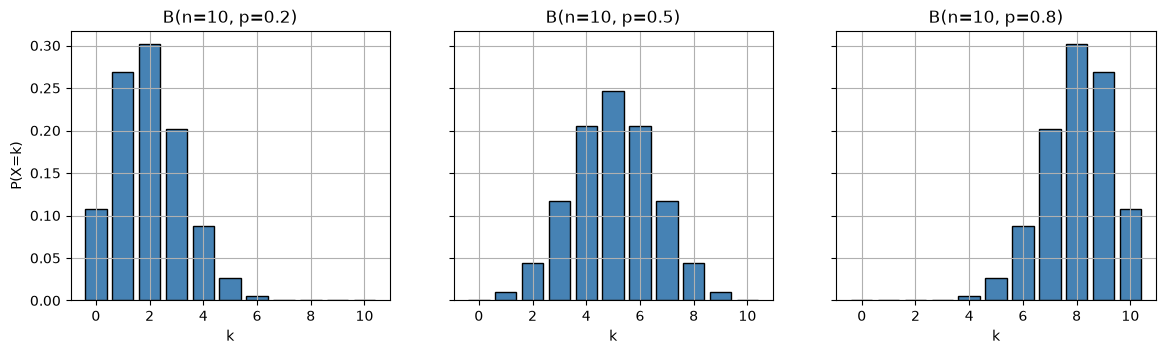

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (n_, p_) in zip(axes, [(10, 0.2), (10, 0.5), (10, 0.8)]):
    k = np.arange(n_ + 1)
    ax.bar(k, stats.binom.pmf(k, n_, p_), color="steelblue", edgecolor="black")
    ax.set_title(f"B(n={n_}, p={p_})"); ax.set_xlabel("k")
axes[0].set_ylabel("P(X=k)")
plt.show()

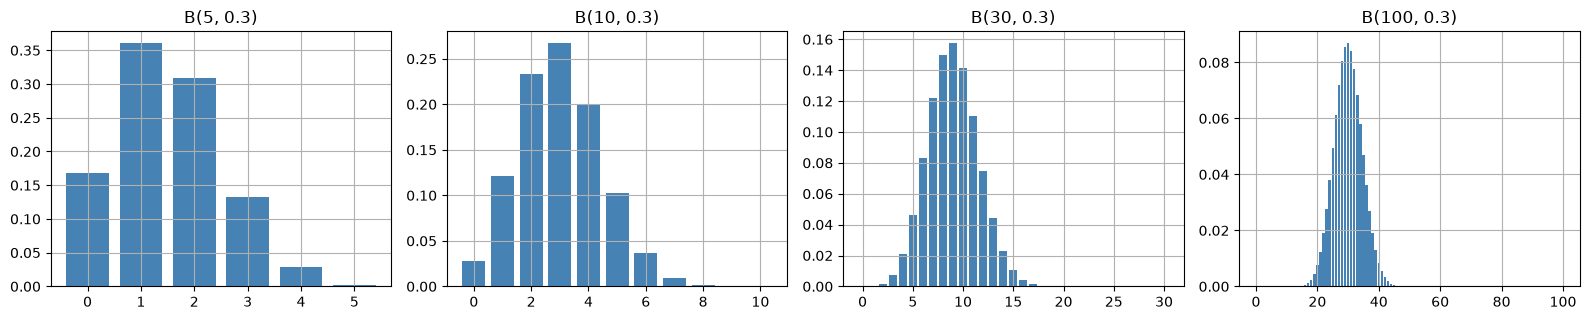

In [8]:
# Effect of n (p fixed)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.3))
for ax, n_ in zip(axes, [5, 10, 30, 100]):
    k = np.arange(n_ + 1)
    ax.bar(k, stats.binom.pmf(k, n_, 0.3), color="steelblue")
    ax.set_title(f"B({n_}, 0.3)")
plt.tight_layout(); plt.show()

## 7. Mean of the Binomial Distribution

$$\boxed{\mu = E[X] = np}$$

### Proof 1: Using indicator (Bernoulli) variables (the easy way)
Write $X = X_1 + X_2 + \dots + X_n$ where each $X_i$ is Bernoulli(p) (1 if trial *i* is a success). By linearity of expectation:

$$E[X]=\sum_{i=1}^n E[X_i]=n\cdot p$$

### Proof 2: Directly from the definition

$$E[X]=\sum_{k=0}^n k\binom{n}{k}p^kq^{n-k}$$

Use $k\binom{n}{k}=n\binom{n-1}{k-1}$:

$$E[X]=np\sum_{k=1}^n\binom{n-1}{k-1}p^{k-1}q^{(n-1)-(k-1)}=np\,(p+q)^{n-1}=np$$

**Intuition:** if you toss a fair coin 100 times, you expect 100 × 0.5 = 50 heads.

In [9]:
n, p = 12, 0.35

k = np.arange(n + 1)
pmf = stats.binom.pmf(k, n, p)

mean_from_definition = np.sum(k * pmf)
print("E[X] from definition  Σ k·P(X=k) :", round(mean_from_definition, 6))
print("Formula np                       :", n * p)
print("scipy .mean()                    :", stats.binom.mean(n, p))

# Verify the identity k*C(n,k) = n*C(n-1,k-1)
print("\nIdentity check k*C(n,k) == n*C(n-1,k-1):",
      all(kk * comb(n, kk) == n * comb(n - 1, kk - 1) for kk in range(1, n + 1)))

E[X] from definition  Σ k·P(X=k) : 4.2
Formula np                       : 4.199999999999999
scipy .mean()                    : 4.199999999999999

Identity check k*C(n,k) == n*C(n-1,k-1): True


## 8. Variance & Standard Deviation of the Binomial Distribution

$$\boxed{\sigma^2=\text{Var}(X)=npq=np(1-p)} \qquad\qquad \boxed{\sigma=\sqrt{npq}}$$

### Proof 1: Using independence (the easy way)
With $X=X_1+\dots+X_n$ and the $X_i$ **independent**, variances add:

$$\text{Var}(X)=\sum_{i=1}^n \text{Var}(X_i)=n\cdot pq$$

### Proof 2: Using $E[X(X-1)]$
$$E[X(X-1)]=\sum_{k=2}^n k(k-1)\binom nk p^kq^{n-k}=n(n-1)p^2\sum_{k=2}^n\binom{n-2}{k-2}p^{k-2}q^{n-k}=n(n-1)p^2$$

Then
$$E[X^2]=E[X(X-1)]+E[X]=n(n-1)p^2+np$$
$$\text{Var}(X)=E[X^2]-(E[X])^2=n(n-1)p^2+np-n^2p^2=np-np^2=np(1-p)=npq$$

### Observations
* Variance is **maximum when p = 0.5** (most uncertainty) and shrinks to 0 as p → 0 or p → 1.
* Since $q = 1-p < 1$, **Var(X) < Mean** for a binomial.
* Standard deviation grows like $\sqrt{n}$, but relative variability (σ/μ) *shrinks* like $1/\sqrt{n}$.

In [10]:
n, p = 12, 0.35
q = 1 - p
k = np.arange(n + 1)
pmf = stats.binom.pmf(k, n, p)

mu = np.sum(k * pmf)
ex2 = np.sum(k**2 * pmf)
efall = np.sum(k * (k - 1) * pmf)                 # E[X(X-1)]

print("E[X(X-1)]  from definition:", round(efall, 6), " | formula n(n-1)p^2 =", round(n*(n-1)*p**2, 6))
print("E[X^2]     from definition:", round(ex2, 6),   " | formula n(n-1)p^2 + np =", round(n*(n-1)*p**2 + n*p, 6))

var_def = ex2 - mu**2
print("\nVariance  E[X^2]-mu^2   :", round(var_def, 6))
print("Variance  npq            :", round(n*p*q, 6))
print("scipy .var()             :", round(stats.binom.var(n, p), 6))
print("\nStd dev  sqrt(npq)       :", round(sqrt(n*p*q), 4))

E[X(X-1)]  from definition: 16.17  | formula n(n-1)p^2 = 16.17
E[X^2]     from definition: 20.37  | formula n(n-1)p^2 + np = 20.37

Variance  E[X^2]-mu^2   : 2.73
Variance  npq            : 2.73
scipy .var()             : 2.73

Std dev  sqrt(npq)       : 1.6523


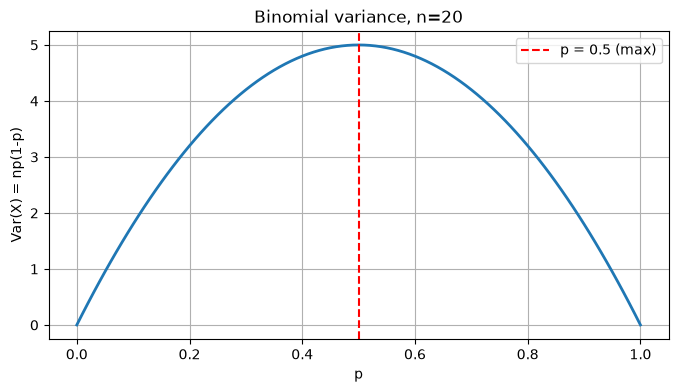

In [11]:
# Variance as a function of p (n fixed): peaks at p = 0.5
n = 20
ps = np.linspace(0, 1, 101)
plt.plot(ps, n * ps * (1 - ps), lw=2)
plt.axvline(0.5, color="red", ls="--", label="p = 0.5 (max)")
plt.xlabel("p"); plt.ylabel("Var(X) = np(1-p)"); plt.title(f"Binomial variance, n={n}")
plt.legend(); plt.show()

In [12]:
# Summary table for several (n, p)
rows = []
for n_, p_ in [(10, 0.5), (10, 0.1), (10, 0.9), (50, 0.5), (100, 0.5), (100, 0.05)]:
    rows.append({"n": n_, "p": p_, "mean np": n_*p_, "variance npq": n_*p_*(1-p_),
                 "std sqrt(npq)": sqrt(n_*p_*(1-p_)), "CV = sd/mean": sqrt(n_*p_*(1-p_))/(n_*p_)})
pd.DataFrame(rows).round(3)

,n,p,mean np,variance npq,std sqrt(npq),CV = sd/mean
0,10,0.50,5.0,2.50,1.581,0.316
1,10,0.10,1.0,0.90,0.949,0.949
2,10,0.90,9.0,0.90,0.949,0.105
3,50,0.50,25.0,12.50,3.536,0.141
4,100,0.50,50.0,25.00,5.000,0.100
5,100,0.05,5.0,4.75,2.179,0.436


## 9. Mode of the Binomial Distribution

The **mode** is the most likely number of successes.

$$\text{Mode} = \lfloor (n+1)p \rfloor$$

* If $(n+1)p$ is **not** an integer → one mode: $\lfloor (n+1)p\rfloor$.
* If $(n+1)p$ **is** an integer → two modes: $(n+1)p$ and $(n+1)p - 1$.

In [13]:
for n_, p_ in [(10, 0.3), (10, 0.5), (9, 0.5), (20, 0.25)]:
    k = np.arange(n_ + 1)
    pm = stats.binom.pmf(k, n_, p_)
    modes_actual = k[np.isclose(pm, pm.max())]
    print(f"B({n_},{p_}): (n+1)p = {(n_+1)*p_:.2f} -> formula floor = {floor((n_+1)*p_)}, actual mode(s) = {[int(m) for m in modes_actual]}")

B(10,0.3): (n+1)p = 3.30 -> formula floor = 3, actual mode(s) = [3]
B(10,0.5): (n+1)p = 5.50 -> formula floor = 5, actual mode(s) = [5]
B(9,0.5): (n+1)p = 5.00 -> formula floor = 5, actual mode(s) = [4, 5]
B(20,0.25): (n+1)p = 5.25 -> formula floor = 5, actual mode(s) = [5]


## 10. Cumulative Probabilities

Real questions are usually about *ranges*:

| Question | Expression | scipy |
|---|---|---|
| Exactly k | P(X = k) | `pmf(k)` |
| At most k | P(X ≤ k) | `cdf(k)` |
| Fewer than k | P(X < k) = P(X ≤ k−1) | `cdf(k-1)` |
| At least k | P(X ≥ k) = 1 − P(X ≤ k−1) | `sf(k-1)` |
| More than k | P(X > k) | `sf(k)` |
| Between a and b (inclusive) | P(a ≤ X ≤ b) | `cdf(b) - cdf(a-1)` |

**"At least one"** trick: $P(X\ge 1)=1-P(X=0)=1-q^n$.

Example: a multiple-choice quiz has 10 questions, each with 4 options. A student guesses every answer. X ~ B(10, 0.25).

In [14]:
n, p = 10, 0.25
X = stats.binom(n, p)

print("P(X = 3)            =", round(X.pmf(3), 4))
print("P(X <= 3)           =", round(X.cdf(3), 4))
print("P(X < 3)            =", round(X.cdf(2), 4))
print("P(X >= 6)  (pass)   =", round(X.sf(5), 4))
print("P(X > 6)            =", round(X.sf(6), 4))
print("P(2 <= X <= 4)      =", round(X.cdf(4) - X.cdf(1), 4))
print("P(at least 1 right) =", round(1 - (1 - p)**n, 4), " = 1 - q^n")

print("\nExpected correct answers:", X.mean(), "| SD:", round(X.std(), 3))

P(X = 3)            = 0.2503
P(X <= 3)           = 0.7759
P(X < 3)            = 0.5256
P(X >= 6)  (pass)   = 0.0197
P(X > 6)            = 0.0035
P(2 <= X <= 4)      = 0.6778
P(at least 1 right) = 0.9437  = 1 - q^n

Expected correct answers: 2.5 | SD: 1.369


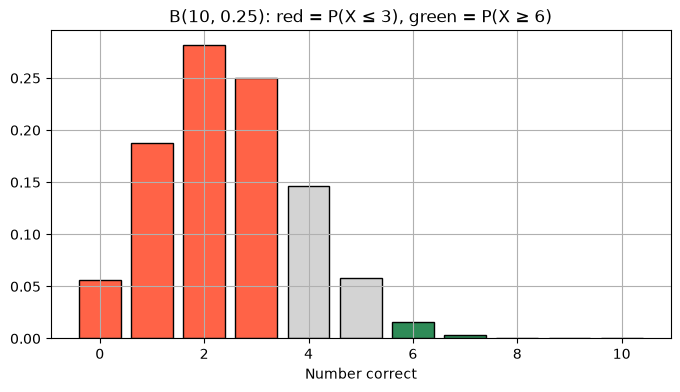

In [15]:
# Visualise "at most 3" and "at least 6"
k = np.arange(n + 1)
colors = ["tomato" if kk <= 3 else ("seagreen" if kk >= 6 else "lightgray") for kk in k]
plt.bar(k, X.pmf(k), color=colors, edgecolor="black")
plt.title("B(10, 0.25): red = P(X ≤ 3), green = P(X ≥ 6)")
plt.xlabel("Number correct"); plt.show()

## 11. Verifying Everything by Simulation

Simulate many repetitions of "run n Bernoulli trials and count successes" and compare with the theory.

Theory : mean=3.000, var=2.100
Flips  : mean=3.002, var=2.098
binomial(): mean=2.997, var=2.101
    empirical  theoretical
0      0.0282       0.0282
1      0.1209       0.1211
2      0.2329       0.2335
3      0.2667       0.2668
4      0.2002       0.2001
5      0.1040       0.1029
6      0.0367       0.0368
7      0.0088       0.0090
8      0.0014       0.0014
9      0.0001       0.0001
10     0.0000       0.0000


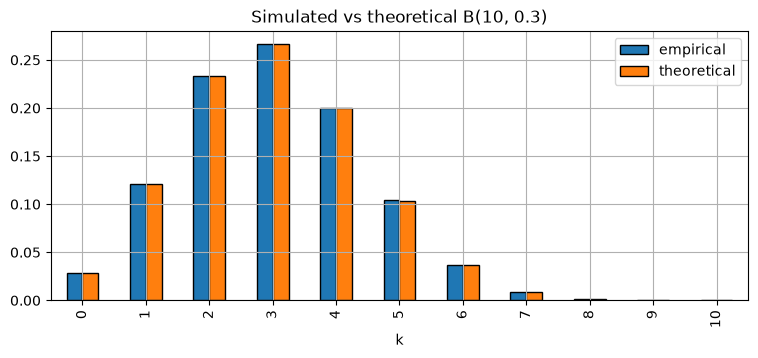

In [16]:
n, p, reps = 10, 0.3, 200_000

# Method 1: literally flip n Bernoulli coins, reps times
flips = rng.random((reps, n)) < p          # True = success
X_sim = flips.sum(axis=1)

# Method 2: numpy's built-in binomial sampler (gives the same distribution)
X_np = rng.binomial(n, p, reps)

print(f"Theory : mean={n*p:.3f}, var={n*p*(1-p):.3f}")
print(f"Flips  : mean={X_sim.mean():.3f}, var={X_sim.var():.3f}")
print(f"binomial(): mean={X_np.mean():.3f}, var={X_np.var():.3f}")

emp = pd.Series(X_sim).value_counts(normalize=True).sort_index()
theo = pd.Series(stats.binom.pmf(np.arange(n + 1), n, p), index=np.arange(n + 1))
comp = pd.DataFrame({"empirical": emp, "theoretical": theo}).fillna(0)
print(comp.round(4))

comp.plot(kind="bar", figsize=(9, 3.5), edgecolor="black")
plt.title("Simulated vs theoretical B(10, 0.3)"); plt.xlabel("k"); plt.show()

## 12. Normal Approximation to the Binomial

When n is large, the binomial looks like a bell curve. It is approximately

$$X \approx N(\mu = np,\ \sigma^2 = npq)$$

**Rule of thumb:** use it when $np \ge 5$ **and** $nq \ge 5$ (some books use 10).

**Continuity correction**: a discrete P(X ≤ k) is approximated by the continuous P(Y ≤ k + 0.5) to improve accuracy.

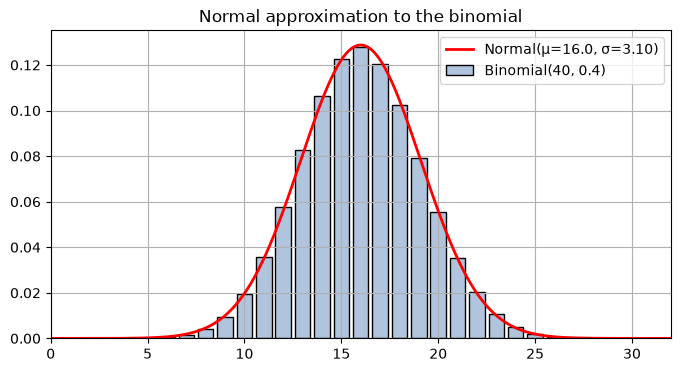

Exact  P(X<=18)            = 0.7911
Normal without correction  = 0.7407
Normal WITH continuity corr = 0.7901  <- closer


In [17]:
n, p = 40, 0.4
mu, sd = n*p, sqrt(n*p*(1-p))
k = np.arange(n + 1)

xs = np.linspace(0, n, 400)
plt.bar(k, stats.binom.pmf(k, n, p), color="lightsteelblue", edgecolor="black", label="Binomial(40, 0.4)")
plt.plot(xs, stats.norm.pdf(xs, mu, sd), "r-", lw=2, label=f"Normal(μ={mu}, σ={sd:.2f})")
plt.xlim(0, 32); plt.legend(); plt.title("Normal approximation to the binomial"); plt.show()

# Compare P(X <= 18)
exact = stats.binom.cdf(18, n, p)
no_cc = stats.norm.cdf(18, mu, sd)
with_cc = stats.norm.cdf(18.5, mu, sd)
print(f"Exact  P(X<=18)            = {exact:.4f}")
print(f"Normal without correction  = {no_cc:.4f}")
print(f"Normal WITH continuity corr = {with_cc:.4f}  <- closer")

## 13. Solved Problems (Textbook Style)

**Problem 1.** A fair coin is tossed 6 times. Find P(exactly 4 heads), P(at least 5 heads) and P(at most 1 head).

In [18]:
X = stats.binom(6, 0.5)
print("P(exactly 4 heads) =", round(X.pmf(4), 5), " = 15/64 =", round(15/64, 5))
print("P(at least 5)      =", round(X.sf(4), 5),  " = 7/64  =", round(7/64, 5))
print("P(at most 1)       =", round(X.cdf(1), 5), " = 7/64")

P(exactly 4 heads) = 0.23438  = 15/64 = 0.23438
P(at least 5)      = 0.10938  = 7/64  = 0.10938
P(at most 1)       = 0.10938  = 7/64


**Problem 2.** The probability that a bulb is defective is 0.05. In a sample of 10 bulbs, find (a) P(no defective), (b) P(at least one defective), (c) the mean and standard deviation of the number of defective bulbs.

In [19]:
X = stats.binom(10, 0.05)
print("(a) P(0 defective)       =", round(X.pmf(0), 4))
print("(b) P(at least 1)        =", round(1 - X.pmf(0), 4))
print("(c) mean =", X.mean(), ", SD =", round(X.std(), 4))

(a) P(0 defective)       = 0.5987
(b) P(at least 1)        = 0.4013
(c) mean = 0.5 , SD = 0.6892


**Problem 3.** A die is thrown 4 times. Find the probability of getting a **six** at least twice.

In [20]:
X = stats.binom(4, 1/6)
print("P(at least two sixes) =", round(X.sf(1), 5))
# manual: 1 - P(0) - P(1)
manual = 1 - (5/6)**4 - 4*(1/6)*(5/6)**3
print("Manual check          =", round(manual, 5))

P(at least two sixes) = 0.13194
Manual check          = 0.13194


**Problem 4.** The mean and variance of a binomial distribution are **4** and **2** respectively. Find n, p and P(X = 1).

*Solution:* $np=4$ and $npq=2$ ⟹ $q = 2/4 = 1/2$, so $p=1/2$ and $n=8$.

In [21]:
mean, var = 4, 2
q = var / mean
p = 1 - q
n = mean / p
print(f"q = {q}, p = {p}, n = {n:.0f}")
print("P(X=1) =", round(stats.binom.pmf(1, int(n), p), 5), " = 8/256 =", round(8/256, 5))

q = 0.5, p = 0.5, n = 8
P(X=1) = 0.03125  = 8/256 = 0.03125


**Problem 5 (finding n).** How many times must a fair coin be tossed so that the probability of **at least one head** is more than 99%?

Need $1-(0.5)^n > 0.99 \Rightarrow (0.5)^n < 0.01 \Rightarrow n > \log(0.01)/\log(0.5) \approx 6.64$.

In [22]:
n = 1
while 1 - 0.5**n <= 0.99:
    n += 1
print("Smallest n:", n, "-> P(at least one head) =", round(1 - 0.5**n, 5))

Smallest n: 7 -> P(at least one head) = 0.99219


**Problem 6 (real-world).** A vaccine works for 90% of people. In a group of 25 vaccinated people, what's the probability that **at most 2** are not protected? What's the expected number not protected?

In [23]:
# X = number NOT protected ~ B(25, 0.10)
X = stats.binom(25, 0.10)
print("P(X <= 2) =", round(X.cdf(2), 4))
print("Expected not protected =", X.mean(), "| SD =", round(X.std(), 3))

P(X <= 2) = 0.5371
Expected not protected = 2.5 | SD = 1.5


## 14. Summary

| Concept | Formula |
|---|---|
| Discrete PMF conditions | 0 ≤ p(x) ≤ 1, Σ p(x) = 1 |
| General mean / variance | μ = Σ x p(x), σ² = Σ x² p(x) − μ² |
| Bernoulli(p) | P(1)=p, P(0)=q; mean p, variance pq |
| Binomial B(n, p) PMF | P(X=k) = C(n,k) pᵏ qⁿ⁻ᵏ |
| **Mean** | **np** |
| **Variance** | **npq** |
| **Standard deviation** | **√(npq)** |
| Mode | ⌊(n+1)p⌋ |
| At least one success | 1 − qⁿ |
| Normal approx. (np, nq ≥ 5) | N(np, npq) with continuity correction |

**Conditions for a binomial: BINS**
* **B**inary outcomes (success / failure)
* **I**ndependent trials
* fixed **N** number of trials
* same **S**uccess probability p every time

**Common mistakes**
1. Using the binomial for sampling *without replacement* from a small population (trials are dependent, so use the hypergeometric distribution).
2. Confusing P(X ≥ k) with 1 − P(X ≤ k) (correct is 1 − P(X ≤ k−1)).
3. Forgetting that variance is **npq**, not **np**.

### Practice problems
1. A coin with P(head)=0.6 is tossed 8 times. Find P(exactly 5 heads), the mean, variance and standard deviation.
2. 5% of items from a machine are defective. In a batch of 15, find P(at most 1 defective).
3. If X ~ B(n, p) has mean 6 and variance 4.2, find n and p.
4. Show that for B(n, p), the variance is maximised at p = 0.5, and find the maximum variance for n = 30.
5. A student guesses on a 20-question true/false test. Find the probability of scoring ≥ 15. Compare the exact answer with the normal approximation (use continuity correction).
6. Simulate 100,000 draws from B(15, 0.2) and verify the mean, variance and mode numerically.